# Loading libraries, datasets and settings  

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls -ahlR "/content/drive/MyDrive/Data Sets/Intermediate"

'/content/drive/MyDrive/Data Sets/Intermediate':
total 20K
drwx------ 2 root root 4.0K Nov  7 20:33  DisGeNET
drwx------ 2 root root 4.0K Nov  7 20:33 'Elliptic Bitcoin Dataset'
drwx------ 2 root root 4.0K Nov  7 20:33 'METR-LA Traffic Dataset'
drwx------ 2 root root 4.0K Nov  7 20:33 'STRING PPI Network'
drwx------ 2 root root 4.0K Nov  7 20:33 'Twitter Higgs Dataset (SNAP)'

'/content/drive/MyDrive/Data Sets/Intermediate/DisGeNET':
total 28M
-rw------- 1 root root 9.4M Nov  7 21:03 all_gene_disease_associations.txt.gz
-rw------- 1 root root 9.1M Nov  7 21:03 befree_gene_disease_associations.txt.gz
-rw------- 1 root root 685K Nov  6 18:09 curated_gene_disease_associations.txt.gz
-rw------- 1 root root 8.9M Nov  7 21:03 literature_gene_disease_associations.txt.gz
-rw------- 1 root root 3.2K Nov  6 18:09 readme.txt

'/content/drive/MyDrive/Data Sets/Intermediate/Elliptic Bitcoin Dataset':
total 512
-rw------- 1 root root 78 Nov  6 18:09 Source.txt

'/content/drive/MyDrive/Data Sets/Inte

In [3]:
!pip -q install networkx tqdm powerlaw python-louvain igraph leidenalg

In [4]:
import gzip
import random
import numpy as np
import networkx as nx
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from time import time
from collections import Counter, defaultdict , deque
import community.community_louvain as community_louvain
from scipy.stats import linregress
import powerlaw
from sklearn.metrics import adjusted_rand_score
import igraph as ig
import leidenalg as la
import math
import matplotlib.cm as cm

Plot defaults

In [5]:
plt.rcParams.update({
"figure.figsize": (7, 4.5),
"axes.grid": True,
"grid.alpha": 0.3,
"axes.spines.top": False,
"axes.spines.right": False,
})

# Part 1 — Cascading Behavior (Linear Threshold & Independent Cascade)

In this section, we construct a subgraph from the Twitter Higgs dataset and simulate two diffusion models:

**1) Linear Threshold (LT)**: A node activates when at least a fraction `theta` of its neighbors are active.  
**2) Independent Cascade (IC)**: Each newly active node gets **one chance** to activate each inactive neighbor with probability `p`.
We focus on a small set of **seed nodes** and study how the cascade size changes as we vary `theta` (LT) and `p` (IC).

## Create a subgraph

We read only the first **200,000** edges to keep the graph manageable and the simulations fast.


In [6]:
def read_first_k_edges_gz(path: str, k: int = 200_000, directed: bool = False) -> nx.Graph:
    edges = []
    with gzip.open(path, "rt") as f:
        for i, line in enumerate(f):
            if i >= k:
                break
            u, v = line.strip().split()
            edges.append((int(u), int(v)))

    G = nx.DiGraph() if directed else nx.Graph()
    G.add_edges_from(edges)
    return G

path = "/content/drive/MyDrive/Data Sets/Intermediate/Twitter Higgs Dataset (SNAP)/higgs-social_network.edgelist.gz"
G = read_first_k_edges_gz(path, k=200_000, directed=False)

print("G:", "n =", G.number_of_nodes(), "m =", G.number_of_edges())

G: n = 52600 m = 193617


## Quick graph summary (essential)

We keep only the most relevant structural indicators:
- **Average degree** (overall connectivity)
- **Degree distribution** (skewness / hubs)
- **Connected components** (fragmentation and largest component size)

These are enough to interpret why cascades may or may not spread widely.


In [7]:
n = G.number_of_nodes()
m = G.number_of_edges()
avg_degree = (2.0 * m) / n if n > 0 else 0.0

print(f"Nodes (n): {n}")
print(f"Edges (m): {m}")
print(f"Average degree: {avg_degree:.4f}")

Nodes (n): 52600
Edges (m): 193617
Average degree: 7.3619


### Degree distribution (log-log) + CCDF

The log-log degree plot helps reveal heavy-tailed behavior.
The **CCDF** is often more stable than raw histograms on log-log axes.


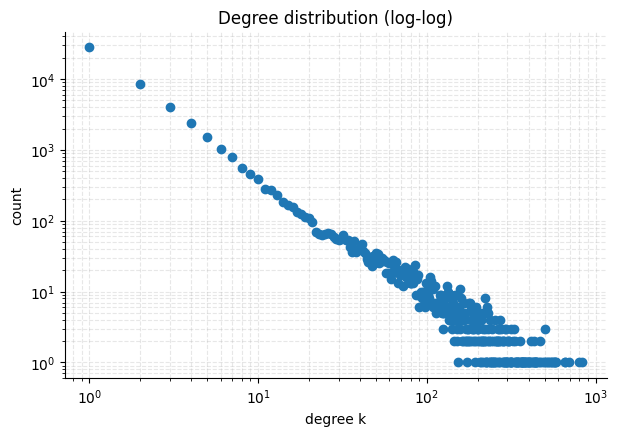

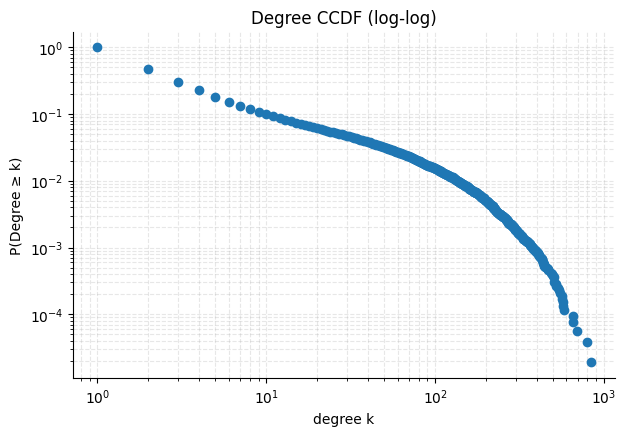

In [8]:
degrees = np.fromiter((d for _, d in G.degree()), dtype=np.int64, count=n)

# Histogram counts by degree value
deg_counts = np.bincount(degrees)
ks = np.nonzero(deg_counts)[0]
counts = deg_counts[ks]

plt.figure()
plt.loglog(ks, counts, marker="o", linestyle="None")
plt.xlabel("degree k")
plt.ylabel("count")
plt.title("Degree distribution (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# CCDF
deg_sorted = np.sort(degrees)
unique_deg = np.unique(deg_sorted)
ccdf = np.array([(deg_sorted >= k).mean() for k in unique_deg])

plt.figure()
plt.loglog(unique_deg, ccdf, marker="o", linestyle="None")
plt.xlabel("degree k")
plt.ylabel("P(Degree ≥ k)")
plt.title("Degree CCDF (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

### Connected components

Cascades can only spread inside a connected component. If the graph is fragmented,
seeds placed in small components will be unable to reach most nodes.


#components: 5
largest component size: 52587
top 10 component sizes: [52587     6     3     2     2]


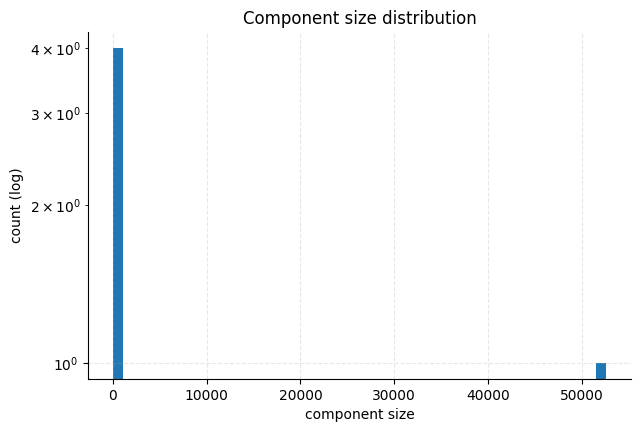

LCC: n = 52587 m = 193608


In [9]:
components = list(nx.connected_components(G))
comp_sizes = np.fromiter((len(c) for c in components), dtype=np.int64)

print(f"#components: {len(comp_sizes)}")
print(f"largest component size: {comp_sizes.max() if len(comp_sizes) else 0}")
print(f"top 10 component sizes: {np.sort(comp_sizes)[-10:][::-1] if len(comp_sizes) else []}")

plt.figure()
plt.hist(comp_sizes, bins=50)
plt.yscale("log")
plt.xlabel("component size")
plt.ylabel("count (log)")
plt.title("Component size distribution")
plt.grid(True, ls="--", alpha=0.3)
plt.show()

# Largest connected component (LCC)
if len(components) > 0:
    lcc_nodes = max(components, key=len)
    G_lcc = G.subgraph(lcc_nodes).copy()
    print("LCC:", "n =", G_lcc.number_of_nodes(), "m =", G_lcc.number_of_edges())
else:
    G_lcc = None


## Selecting initial active nodes (seeds)

We choose a fixed-size random seed set for reproducibility.


In [10]:
def get_initial_seeds(G: nx.Graph, k: int = 20, seed: int = 42):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    return rng.sample(nodes, k)


seeds = get_initial_seeds(G, k=20, seed=42)
print("Seed sample (first 10):", seeds[:10])


Seed sample (first 10): [41906, 7297, 1640, 48599, 18025, 16050, 14629, 9145, 48266, 6718]


## Task 1: Linear Threshold (LT)

**Rule:** A node activates if:

$$
\frac{\#(\text{active neighbors})}{\deg(u)} \ge \theta
$$

**Interpretation:** Larger `theta` means a node needs stronger social reinforcement
(more neighbors active) before it adopts.


In [11]:
def linear_threshold(G: nx.Graph, seeds, theta: float = 0.5, max_steps: int = 10_000):
    active = set(seeds)
    history = [len(active)]

    # Precompute neighbor lists and degrees (speed)
    neighbors = {u: list(G.neighbors(u)) for u in G.nodes()}
    deg = {u: len(neighbors[u]) for u in G.nodes()}

    for _ in range(max_steps):
        newly_active = set()

        for u in G.nodes():
            if u in active or deg[u] == 0:
                continue

            active_nbrs = sum((v in active) for v in neighbors[u])
            if (active_nbrs / deg[u]) >= theta:
                newly_active.add(u)

        if not newly_active:
            break

        active |= newly_active
        history.append(len(active))

    return active, history

### LT with θ = 0.50

With a high threshold, adoption usually requires strong local agreement,
so cascades often stall quickly.

LT(theta=0.50): final active = 37 steps = 1 fraction = 0.0007034220532319391


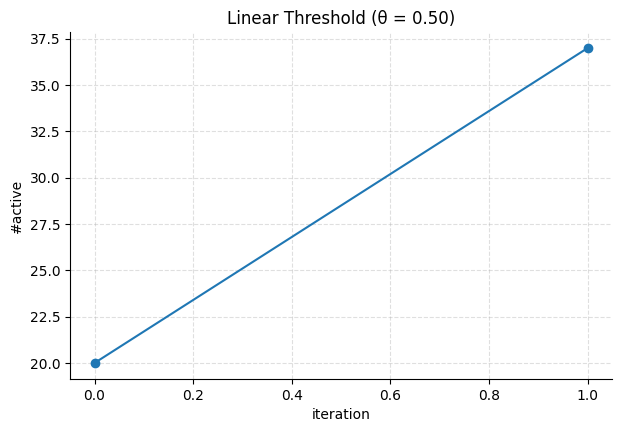

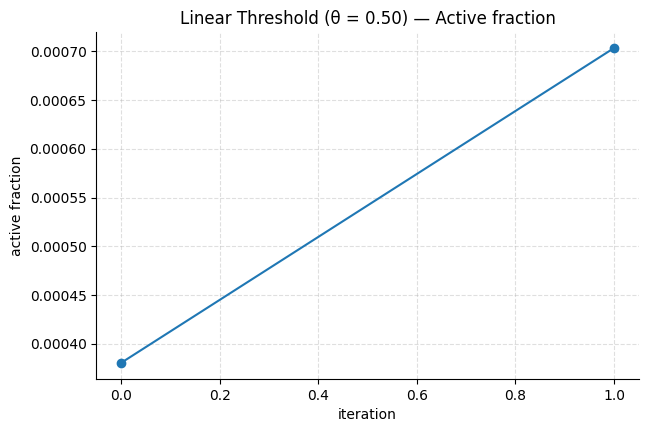

In [12]:
active_final, hist = linear_threshold(G, seeds, theta=0.50, max_steps=50_000)

print(
    "LT(theta=0.50):",
    "final active =", len(active_final),
    "steps =", len(hist) - 1,
    "fraction =", (len(active_final) / n) if n else 0.0,
)

plt.figure()
plt.plot(range(len(hist)), hist, marker="o")
plt.xlabel("iteration")
plt.ylabel("#active")
plt.title("Linear Threshold (θ = 0.50)")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

plt.figure()
plt.plot(range(len(hist)), np.array(hist) / n, marker="o")
plt.xlabel("iteration")
plt.ylabel("active fraction")
plt.title("Linear Threshold (θ = 0.50) — Active fraction")
plt.grid(True, ls="--", alpha=0.4)
plt.show()


**Explanation (θ = 0.50):**

Requiring **50% of neighbors** to be active is a strong condition in sparse or moderately sparse graphs.
Even if a node has several active neighbors, it may still fail the 50% rule—especially for higher-degree nodes.
As a result, only nodes that are very locally dense around the initial seeds tend to activate, and the process
typically stops after very few iterations.
Here it has stopped after first iteration.

### LT with θ = 0.07

Lower thresholds reduce the social reinforcement needed to activate, so the cascade can spread much further.


LT(theta=0.07): final active = 52515 steps = 13 fraction = 0.998384030418251


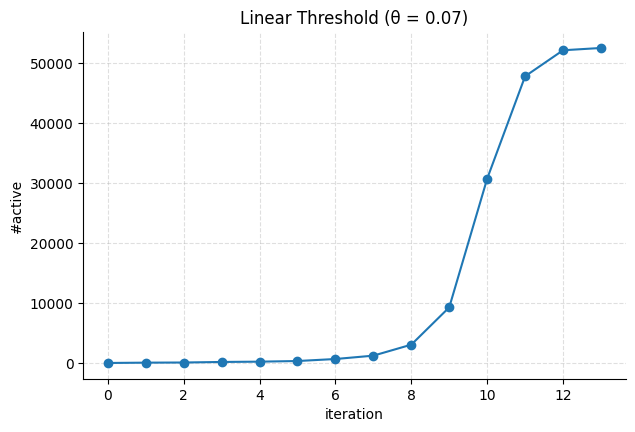

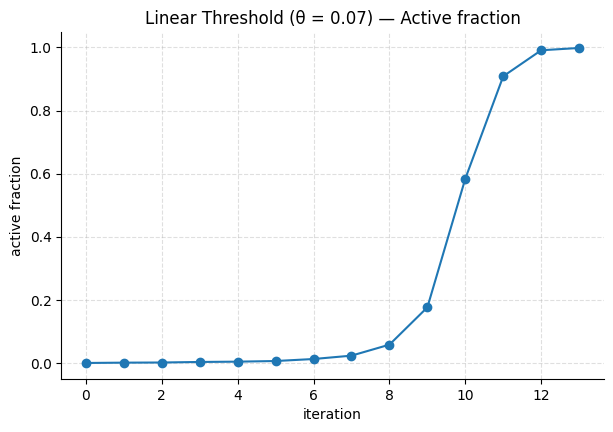

In [13]:
active_final, hist = linear_threshold(G, seeds, theta=0.07, max_steps=20)

print(
    "LT(theta=0.07):",
    "final active =", len(active_final),
    "steps =", len(hist) - 1,
    "fraction =", (len(active_final) / n) if n else 0.0,
)

plt.figure()
plt.plot(range(len(hist)), hist, marker="o")
plt.xlabel("iteration")
plt.ylabel("#active")
plt.title("Linear Threshold (θ = 0.07)")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

plt.figure()
plt.plot(range(len(hist)), np.array(hist) / n, marker="o")
plt.xlabel("iteration")
plt.ylabel("active fraction")
plt.title("Linear Threshold (θ = 0.07) — Active fraction")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

**Explanation (θ = 0.07):**

With `θ = 0.07`, a node needs only **7%** of its neighbors active to adopt.
This condition is much easier to satisfy, so activation can propagate quickly across the network.
In practice, small thresholds often produce a large cascade, especially if seeds lie inside the giant component.


## Task 2: Independent Cascade (IC)

**Rule:** When a node becomes newly active, it gets **one attempt** to activate each inactive neighbor,
succeeding independently with probability `p`.

Since IC is stochastic, we run multiple simulations and report mean/std of final cascade size.


In [14]:
def independent_cascade(G: nx.Graph, seeds, p: float = 0.1, rng=None, max_steps: int = 10_000):
    if rng is None:
        rng = random.Random()

    active = set(seeds)
    frontier = set(seeds)  # newly active in the current step
    history = [len(active)]

    step = 0
    while frontier and step < max_steps:
        step += 1
        next_frontier = set()

        for u in frontier:
            for v in G.neighbors(u):
                if v in active:
                    continue
                if rng.random() < p:
                    next_frontier.add(v)

        frontier = next_frontier - active
        active |= frontier
        history.append(len(active))

    return active, history


def run_ic_many(G: nx.Graph, seeds, p: float = 0.1, runs: int = 50, seed: int = 123):
    rng_master = random.Random(seed)
    final_sizes = []
    histories = []

    for _ in tqdm(range(runs)):
        rseed = rng_master.randint(0, 10**9)
        active, hist = independent_cascade(G, seeds, p=p, rng=random.Random(rseed))
        final_sizes.append(len(active))
        histories.append(hist)

    return np.array(final_sizes, dtype=np.int64), histories


def mean_history(histories):
    max_len = max(len(h) for h in histories)
    H = np.zeros((len(histories), max_len), dtype=float)
    for i, h in enumerate(histories):
        H[i, : len(h)] = h
        H[i, len(h) :] = h[-1]  # pad with last value
    return H.mean(axis=0), H.std(axis=0)

### IC with p = 0.10 (50 runs)

100%|██████████| 50/50 [00:02<00:00, 17.62it/s]


IC(p=0.10): mean final size = 12396.86 std = 102.08878684752797
IC(p=0.10): min/max = 12153 12663


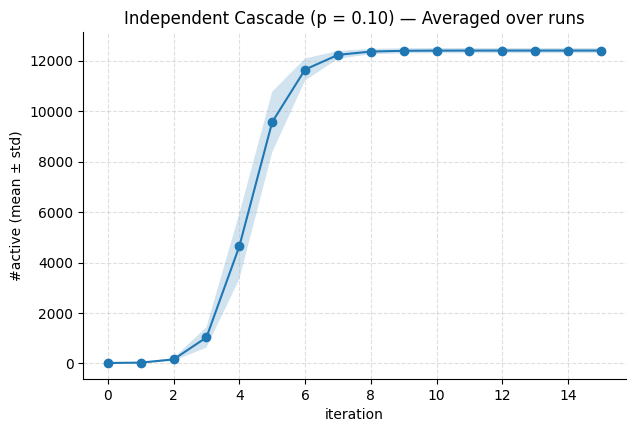

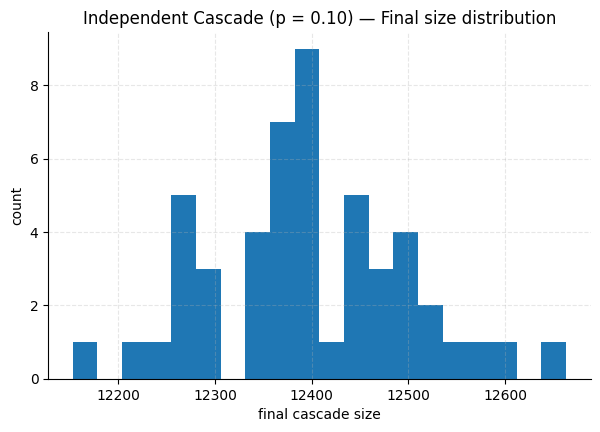

In [15]:
sizes, histories = run_ic_many(G, seeds, p=0.10, runs=50, seed=123)

print("IC(p=0.10): mean final size =", float(np.mean(sizes)), "std =", float(np.std(sizes)))
print("IC(p=0.10): min/max =", int(np.min(sizes)), int(np.max(sizes)))

m_hist, s_hist = mean_history(histories)

plt.figure()
plt.plot(range(len(m_hist)), m_hist, marker="o")
plt.fill_between(range(len(m_hist)), m_hist - s_hist, m_hist + s_hist, alpha=0.2)
plt.xlabel("iteration")
plt.ylabel("#active (mean ± std)")
plt.title("Independent Cascade (p = 0.10) — Averaged over runs")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

plt.figure()
plt.hist(sizes, bins=20)
plt.xlabel("final cascade size")
plt.ylabel("count")
plt.title("Independent Cascade (p = 0.10) — Final size distribution")
plt.grid(True, ls="--", alpha=0.3)
plt.show()

### IC with p = 0.20 (50 runs)

100%|██████████| 50/50 [00:06<00:00,  7.25it/s]


IC(p=0.20): mean final size = 20192.66 std = 91.35066721157541
IC(p=0.20): min/max = 20018 20434


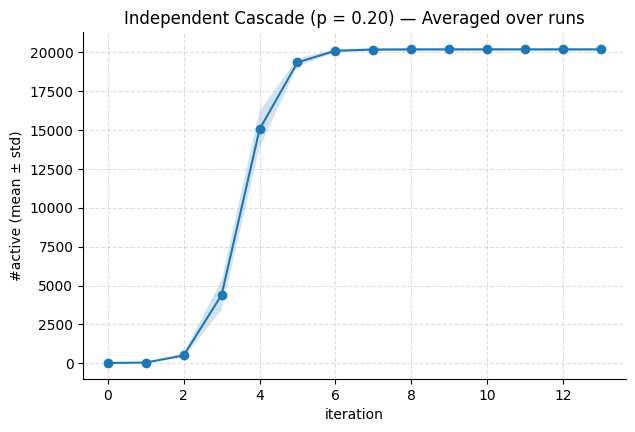

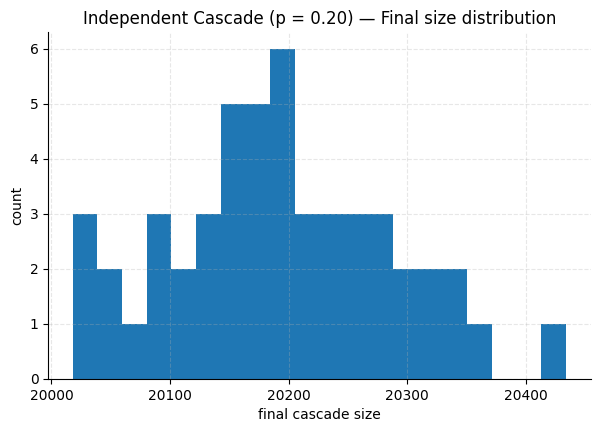

In [16]:
sizes, histories = run_ic_many(G, seeds, p=0.20, runs=50, seed=123)

print("IC(p=0.20): mean final size =", float(np.mean(sizes)), "std =", float(np.std(sizes)))
print("IC(p=0.20): min/max =", int(np.min(sizes)), int(np.max(sizes)))

m_hist, s_hist = mean_history(histories)

plt.figure()
plt.plot(range(len(m_hist)), m_hist, marker="o")
plt.fill_between(range(len(m_hist)), m_hist - s_hist, m_hist + s_hist, alpha=0.2)
plt.xlabel("iteration")
plt.ylabel("#active (mean ± std)")
plt.title("Independent Cascade (p = 0.20) — Averaged over runs")
plt.grid(True, ls="--", alpha=0.4)
plt.show()

plt.figure()
plt.hist(sizes, bins=20)
plt.xlabel("final cascade size")
plt.ylabel("count")
plt.title("Independent Cascade (p = 0.20) — Final size distribution")
plt.grid(True, ls="--", alpha=0.3)
plt.show()

## Compraring the Methods

In the Independent Cascade (IC) model, diffusion is probabilistic and incremental: each newly active node gets only one chance to activate each neighbor with probability $p$. As a result, activation often proceeds more slowly from step to step, but even nodes in sparse regions or with high degree still have a non-zero chance of becoming active over time, which can lead to a broader overall spread. In contrast, the Linear Threshold (LT) model is deterministic and reinforcement-based: once the fraction of active neighbors exceeds the threshold, a node activates immediately, making the diffusion faster when local conditions are satisfied. However, if the threshold is relatively high or the network lacks sufficient local reinforcement, many nodes never meet the activation condition, causing the cascade to stop early and remain more limited.

# 2. Power Laws and Preferential Attachment

In this section, we study **power-law degree distributions** and the
**preferential attachment mechanism** using the Barabási–Albert (BA) model.
The main idea behind preferential attachment is that nodes with higher degree
are more likely to attract new connections (“the rich get richer”), which
naturally leads to **heavy-tailed degree distributions**.

We first generate a synthetic BA graph and analyze its degree distribution.
Then, we compare the results with a real-world biological network
(DisGeNET) to assess similarities and differences between idealized models
and empirical data.


## Helper functions

- `degree_distribution`: computes the empirical degree distribution.
- `fit_powerlaw_linear_loglog`: performs a linear fit on log-log data,
  as explicitly requested in the problem statement.


In [17]:
def degree_distribution(degrees, normalize=True):
    """
    Compute degree distribution.

    Parameters
    ----------
    degrees : iterable
        Node degrees.
    normalize : bool
        If True, return probabilities P(k). Otherwise, return raw counts.

    Returns
    -------
    k : np.ndarray
        Sorted unique degree values.
    pk : np.ndarray
        Probability (or count) associated with each degree.
    """
    counts = Counter(degrees)
    k = np.array(sorted(counts.keys()))
    v = np.array([counts[ki] for ki in k], dtype=float)
    if normalize:
        v /= v.sum()
    return k, v


def fit_powerlaw_linear_loglog(k, pk, kmin=1):
    """
    Linear regression on log-log transformed data:
        log(P(k)) = a * log(k) + b
    Power-law exponent: alpha = -a

    Parameters
    ----------
    k : np.ndarray
        Degree values.
    pk : np.ndarray
        Degree probabilities.
    kmin : int
        Minimum degree included in the fit.

    Returns
    -------
    alpha : float
        Estimated power-law exponent.
    slope : float
        Regression slope.
    intercept : float
        Regression intercept.
    r2 : float
        Coefficient of determination.
    """
    mask = (k >= kmin) & (pk > 0)
    x = np.log10(k[mask])
    y = np.log10(pk[mask])
    res = linregress(x, y)
    alpha = -res.slope
    return alpha, res.slope, res.intercept, res.rvalue ** 2


## Task 1: Barabási–Albert graph

We generate a BA graph with:
- **n = 5000 nodes**
- **m = 3 edges per new node**

According to theory, the BA model should produce a power-law degree
distribution with exponent close to **α ≈ 3** (in the asymptotic limit).


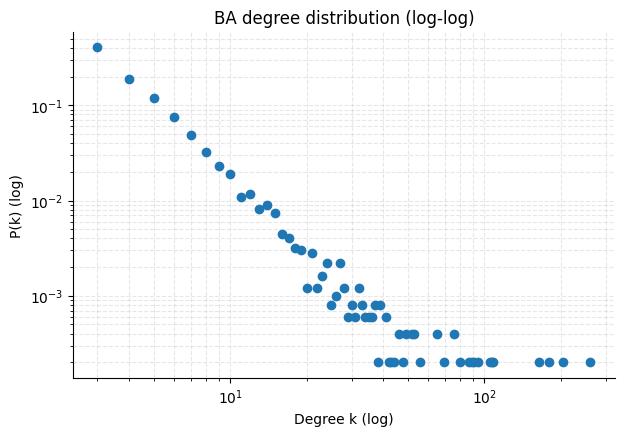

[BA | Linear fit on log-log] slope=-1.9009 => alpha=1.9009 | R^2=0.8563


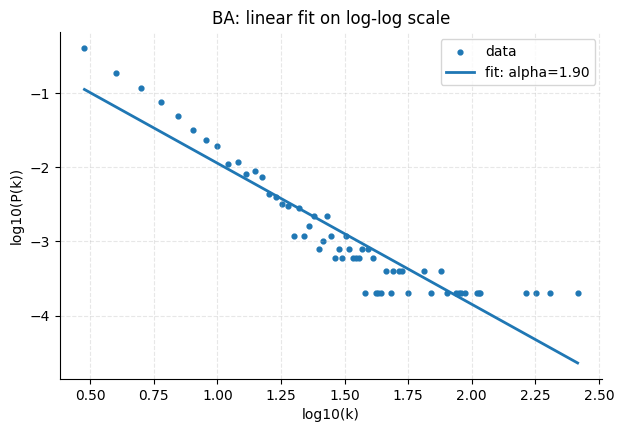

[BA | MLE powerlaw] alpha=2.7903, xmin=5.0


In [18]:
n = 5000
m = 3

G_ba = nx.barabasi_albert_graph(n=n, m=m, seed=42)

deg_ba = np.array([d for _, d in G_ba.degree()])
k_ba, pk_ba = degree_distribution(deg_ba, normalize=True)

# Degree distribution (log-log)
plt.figure()
plt.loglog(k_ba, pk_ba, marker="o", linestyle="none")
plt.xlabel("Degree k (log)")
plt.ylabel("P(k) (log)")
plt.title("BA degree distribution (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# Linear fit on log-log data (as required)
alpha_lin, slope, intercept, r2 = fit_powerlaw_linear_loglog(k_ba, pk_ba, kmin=m)
print(
    f"[BA | Linear fit on log-log] "
    f"slope={slope:.4f} => alpha={alpha_lin:.4f} | R^2={r2:.4f}"
)

# Visualization of the fit
x = np.log10(k_ba[k_ba >= m])
yhat = slope * x + intercept
plt.figure()
plt.scatter(np.log10(k_ba[k_ba >= m]), np.log10(pk_ba[k_ba >= m]), s=12, label="data")
plt.plot(x, yhat, linewidth=2, label=f"fit: alpha={alpha_lin:.2f}")
plt.xlabel("log10(k)")
plt.ylabel("log10(P(k))")
plt.title("BA: linear fit on log-log scale")
plt.legend()
plt.grid(True, ls="--", alpha=0.3)
plt.show()

# MLE-based fit (more robust, reported for comparison)
fit_ba = powerlaw.Fit(deg_ba, discrete=True, verbose=False)
print(f"[BA | MLE powerlaw] alpha={fit_ba.alpha:.4f}, xmin={fit_ba.xmin}")



**Discussion (BA model):**

- The **log-log linear fit** yields an exponent **α ≈ 1.90** with reasonably
  high \(R^2\), indicating approximate linearity on log-log axes.
- The **MLE-based estimate** gives **α ≈ 2.79**, which is much closer to the
  theoretical value (~3) expected for the BA model.

This discrepancy highlights a known issue: **linear regression on log-log data
tends to bias the exponent**, especially for finite-size networks.
Maximum-likelihood estimation is statistically more reliable.


## Task 2: DisGeNET (real-world network)

We now repeat the same analysis on the DisGeNET gene–disease association network.
This graph is bipartite in nature (genes–diseases) and reflects real biological data.


In [19]:
path = "/content/drive/MyDrive/Data Sets/Intermediate/DisGeNET/all_gene_disease_associations.txt.gz"

gene_col = "geneId"
disease_col = "diseaseId"

G_dis = nx.Graph()
chunk_size = 500_000

reader = pd.read_csv(
    path,
    sep="\t",
    compression="gzip",
    usecols=[gene_col, disease_col],
    chunksize=chunk_size,
    low_memory=True,
)

for i, df in enumerate(reader, start=1):
    genes = "G:" + df[gene_col].astype(str)
    diseases = "D:" + df[disease_col].astype(str)
    edges = list(zip(genes, diseases))
    G_dis.add_edges_from(edges)
    print(
        f"chunk {i}: edges added={len(edges):,} | "
        f"nodes={G_dis.number_of_nodes():,} | "
        f"edges={G_dis.number_of_edges():,}"
    )

print(
    "Final DisGeNET graph:",
    G_dis.number_of_nodes(),
    "nodes |",
    G_dis.number_of_edges(),
    "edges",
)


chunk 1: edges added=429,111 | nodes=31,800 | edges=429,111
Final DisGeNET graph: 31800 nodes | 429111 edges


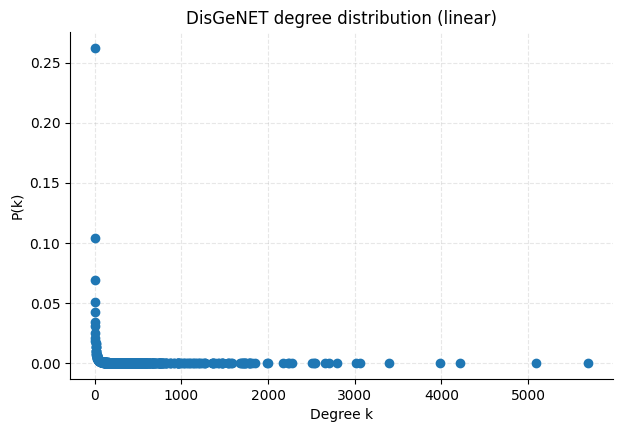

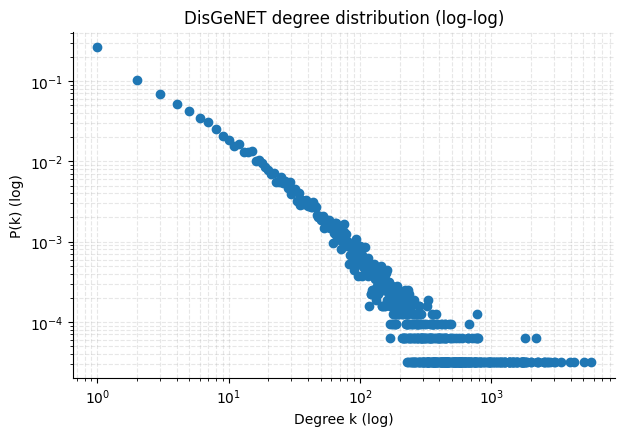

[DisGeNET | Linear fit on log-log] slope=-1.2891 => alpha=1.2891 | R^2=0.8260
[DisGeNET | MLE powerlaw] alpha=2.3905, xmin=126.0
Compare power_law vs lognormal: R=-2.7057, p=0.1341


In [20]:
deg_dis = np.array([d for _, d in G_dis.degree()])
k_dis, pk_dis = degree_distribution(deg_dis, normalize=True)

# Linear-scale distribution
plt.figure()
plt.plot(k_dis, pk_dis, marker="o", linestyle="none")
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.title("DisGeNET degree distribution (linear)")
plt.grid(True, ls="--", alpha=0.3)
plt.show()

# Log-log distribution
plt.figure()
plt.loglog(k_dis, pk_dis, marker="o", linestyle="none")
plt.xlabel("Degree k (log)")
plt.ylabel("P(k) (log)")
plt.title("DisGeNET degree distribution (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# Linear fit on log-log data
alpha_dis_lin, slope_dis, intercept_dis, r2_dis = fit_powerlaw_linear_loglog(
    k_dis, pk_dis, kmin=3
)
print(
    f"[DisGeNET | Linear fit on log-log] "
    f"slope={slope_dis:.4f} => alpha={alpha_dis_lin:.4f} | R^2={r2_dis:.4f}"
)

# MLE fit
fit_dis = powerlaw.Fit(deg_dis, discrete=True, verbose=False)
print(
    f"[DisGeNET | MLE powerlaw] "
    f"alpha={fit_dis.alpha:.4f}, xmin={fit_dis.xmin}"
)

# Power-law vs lognormal comparison
R, p = fit_dis.distribution_compare("power_law", "lognormal")
print(f"Compare power_law vs lognormal: R={R:.4f}, p={p:.4g}")



**Discussion (DisGeNET):**

- The log-log plot shows a **heavy-tailed** degree distribution, but with
  more curvature and noise than the BA model.
- The linear log-log fit gives **α ≈ 1.29**, which is significantly smaller
  than the BA exponent and suggests deviations from a pure power law.
- The MLE estimate (**α ≈ 2.39**, with large `xmin`) indicates that only the
  extreme tail may follow power-law behavior.
- The comparison with a lognormal distribution yields a **non-significant p-value**,
  meaning that a lognormal distribution cannot be ruled out.

**Conclusion:**
While the BA model cleanly produces power-law degree distributions through
preferential attachment, real-world networks like DisGeNET exhibit more complex
structure. They may show heavy tails, but not necessarily a pure power law over
the entire degree range.


# 3. Random Walk (PageRank and Random Walk with Restart)

In this part we use the **STRING PPI network** (protein–protein interactions) and compute:

**Task 1 — PageRank:** Compute PageRank score for every protein, report the **top-5** proteins, and check whether
they correspond to **high-degree / hub-like nodes** or have special structural roles.

**Task 2 — Random Walk with Restart (RWR):** Run a personalized random walk starting from a **seed protein**
with restart probability **15%**, report the **top-5 most similar proteins**, and analyze whether these proteins are
related to the seed (e.g., direct neighbors or strongly connected via the network).

Finally, we vary the restart probability and analyze how the algorithm behavior changes.


## Download and load STRING physical links
The STRING file contains edges with a confidence score in the range **0..1000**.
We optionally filter edges by `SCORE_THRESHOLD` to keep only high-confidence interactions.


In [21]:
!wget -O 9606.protein.links.v12.0.txt.gz "https://stringdb-downloads.org/download/protein.physical.links.v12.0/9606.protein.physical.links.v12.0.txt.gz"
!gunzip -f 9606.protein.links.v12.0.txt.gz
!ls -lh

--2026-02-04 17:41:27--  https://stringdb-downloads.org/download/protein.physical.links.v12.0/9606.protein.physical.links.v12.0.txt.gz
Resolving stringdb-downloads.org (stringdb-downloads.org)... 49.12.123.75
Connecting to stringdb-downloads.org (stringdb-downloads.org)|49.12.123.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8954065 (8.5M) [application/octet-stream]
Saving to: ‘9606.protein.links.v12.0.txt.gz’

9606.protein.links. 100%[===================>]   8.54M  4.65MB/s    in 1.8s    

2026-02-04 17:41:30 (4.65 MB/s) - ‘9606.protein.links.v12.0.txt.gz’ saved [8954065/8954065]

total 65M
-rw-r--r-- 1 root root  65M May 17  2023 9606.protein.links.v12.0.txt
drwx------ 5 root root 4.0K Feb  4 14:37 drive
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data


In [22]:
!head 9606.protein.links.v12.0.txt

protein1 protein2 combined_score
9606.ENSP00000000233 9606.ENSP00000257770 311
9606.ENSP00000000233 9606.ENSP00000226004 161
9606.ENSP00000000233 9606.ENSP00000434442 499
9606.ENSP00000000233 9606.ENSP00000262455 531
9606.ENSP00000000233 9606.ENSP00000303145 499
9606.ENSP00000000233 9606.ENSP00000263265 292
9606.ENSP00000000233 9606.ENSP00000365686 221
9606.ENSP00000000233 9606.ENSP00000280706 219
9606.ENSP00000000233 9606.ENSP00000426503 292


In [23]:
!wc -l 9606.protein.links.v12.0.txt

1477611 9606.protein.links.v12.0.txt


## Configuration

In [24]:
PATH = "/content/9606.protein.links.v12.0.txt"

SCORE_THRESHOLD = 400          # 0..1000 ; set None to keep all edges (may be slow)
USE_WEIGHT = True              # use combined_score as edge weight
WEIGHT_SCALE = 1 / 1000        # normalize 0..1000 -> 0..1

PAGERANK_ALPHA = 0.85          # damping factor; teleport probability = 1 - alpha
PAGERANK_TOL = 1e-8
PAGERANK_MAXIT = 200

SEED = "9606.ENSP00000000233"  # seed protein for RWR (must exist in graph)

RWR_RESTART = 0.15             # restart probability
RWR_ALPHA = 1 - RWR_RESTART    # in nx.pagerank: alpha = prob of following edges


## Build the PPI graph

In [25]:
dtypes = {
    "protein1": "string",
    "protein2": "string",
    "combined_score": "int16",  # 0..1000 fits in int16
}

df = pd.read_csv(
    PATH,
    sep=r"\s+|\t+",
    engine="python",
    usecols=["protein1", "protein2", "combined_score"],
    dtype=dtypes,
)

print("Loaded edges:", len(df))
print(df.head())

Loaded edges: 1477610
               protein1              protein2  combined_score
0  9606.ENSP00000000233  9606.ENSP00000257770             311
1  9606.ENSP00000000233  9606.ENSP00000226004             161
2  9606.ENSP00000000233  9606.ENSP00000434442             499
3  9606.ENSP00000000233  9606.ENSP00000262455             531
4  9606.ENSP00000000233  9606.ENSP00000303145             499


In [26]:
if SCORE_THRESHOLD is not None:
    before = len(df)
    df = df[df["combined_score"] >= SCORE_THRESHOLD].copy()
    print(f"Filtered by score>={SCORE_THRESHOLD}: {before} -> {len(df)} edges")

if USE_WEIGHT:
    df["weight"] = df["combined_score"].astype("float32") * WEIGHT_SCALE
    G = nx.from_pandas_edgelist(df, "protein1", "protein2", edge_attr="weight", create_using=nx.Graph)
    weight_attr = "weight"
else:
    G = nx.from_pandas_edgelist(df, "protein1", "protein2", create_using=nx.Graph)
    weight_attr = None

print("Graph built")
print("n =", G.number_of_nodes(), "m =", G.number_of_edges())

deg = dict(G.degree())
print("Average degree:", 2 * G.number_of_edges() / G.number_of_nodes())


Filtered by score>=400: 1477610 -> 421334 edges
Graph built
n = 15809 m = 210667
Average degree: 26.651527610854576


## Task 1 — PageRank on PPI network

**What PageRank captures in PPI graphs**
- PageRank rewards nodes that are connected to other well-connected nodes.
- In undirected graphs, PageRank is often strongly correlated with degree, but it is not identical:
  nodes connected to hubs can also gain high score even if their own degree is moderate.

**Required output:** report the **top-5 PageRank proteins** and compare them with high-degree nodes.


In [27]:
t0 = time()
pr = nx.pagerank(
    G,
    alpha=PAGERANK_ALPHA,
    weight=weight_attr,
    tol=PAGERANK_TOL,
    max_iter=PAGERANK_MAXIT,
)
print("PageRank computed in", round(time() - t0, 2), "sec")

top5_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop-5 PageRank:")
for node, score in top5_pr:
    print(f"{node}\tPR={score:.6e}\tdeg={deg.get(node, 0)}")

PageRank computed in 0.47 sec

Top-5 PageRank:
9606.ENSP00000253024	PR=4.178035e-03	deg=469
9606.ENSP00000272317	PR=1.464638e-03	deg=898
9606.ENSP00000441543	PR=1.364716e-03	deg=719
9606.ENSP00000388107	PR=1.293243e-03	deg=801
9606.ENSP00000269305	PR=1.283094e-03	deg=612


**Answer / analysis (Task 1):**

In PPI networks, the nodes with the highest PageRank are typically **global hubs** or proteins that lie in
densely connected regions. Since this graph is undirected, PageRank is usually **positively correlated**
with degree. Therefore, if the top PageRank nodes also have very high degree, this is expected and indicates
that they act as **central interaction hubs**.

If a top PageRank node does *not* have the highest degree, it may still rank highly because it is connected
to other important nodes (high-degree or high-PageRank neighbors), meaning it sits in a strategically central
neighborhood rather than being a hub itself.


### Extra visualization (degree vs PageRank)

This plot helps check whether PageRank is mostly degree-driven in this network.


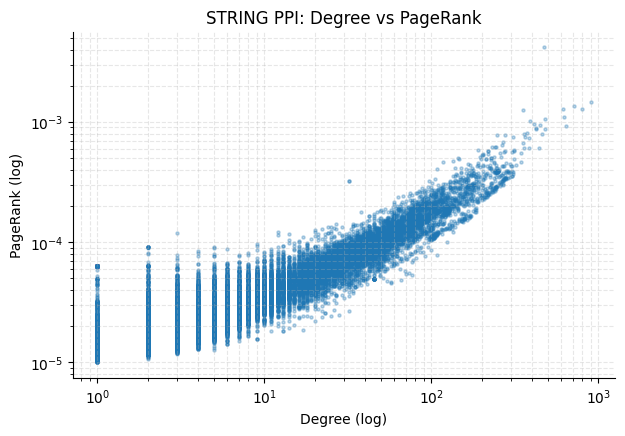

In [28]:
pr_values = np.array([pr[v] for v in G.nodes()], dtype=float)
deg_values = np.array([deg[v] for v in G.nodes()], dtype=float)

plt.figure()
plt.scatter(deg_values, pr_values, s=5, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("PageRank (log)")
plt.title("STRING PPI: Degree vs PageRank")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

## Task 2 — Random Walk with Restart (RWR)

RWR is a **personalized PageRank**:
- With probability `(1 - restart)` the walker follows edges
- With probability `restart` it jumps back to the **seed**

The stationary probability of each node can be interpreted as a **similarity score** to the seed:
nodes that are closer (directly or through many short paths) receive higher scores.

**Required output:** report the **top-5 nodes** with highest similarity to the seed and analyze whether
they are related to the seed (e.g., are they direct neighbors).


In [29]:
if SEED not in G:
    print("\n[Warning] Seed not found in graph:", SEED)
else:
    personalization = {node: 0.0 for node in G.nodes()}
    personalization[SEED] = 1.0

    t0 = time()
    rwr = nx.pagerank(
        G,
        alpha=RWR_ALPHA,
        personalization=personalization,
        weight=weight_attr,
        tol=PAGERANK_TOL,
        max_iter=PAGERANK_MAXIT,
    )
    print("RWR computed in", round(time() - t0, 2), "sec")

    top_sim = sorted(rwr.items(), key=lambda x: x[1], reverse=True)
    top_sim = [(n, s) for n, s in top_sim if n != SEED][:5]

    print(f"\nSeed={SEED} restart={RWR_RESTART}")
    print("Top-5 RWR similar nodes:")
    seed_neighbors = set(G.neighbors(SEED))
    for node, score in top_sim:
        print(f"{node}\tRWR={score:.6e}\tdeg={deg.get(node,0)}\tis_neighbor={node in seed_neighbors}")


RWR computed in 0.46 sec

Seed=9606.ENSP00000000233 restart=0.15
Top-5 RWR similar nodes:
9606.ENSP00000357048	RWR=1.118592e-02	deg=50	is_neighbor=True
9606.ENSP00000325002	RWR=1.109176e-02	deg=48	is_neighbor=True
9606.ENSP00000402346	RWR=1.105643e-02	deg=48	is_neighbor=True
9606.ENSP00000329419	RWR=1.094269e-02	deg=42	is_neighbor=True
9606.ENSP00000249923	RWR=1.094254e-02	deg=56	is_neighbor=True


**Answer / analysis (Task 2):**

The RWR top-5 nodes now have close scores (on the order of
10−2
10
−2
), rather than one node dominating the distribution. This is a typical and desirable outcome: it indicates the seed has multiple strong short paths to a local neighborhood instead of being attached to a single high-confidence neighbor. The top-ranked nodes should be interpreted as the proteins that are most proximal to the seed under the random-walk-with-restart dynamics; in practice, these are usually direct neighbors or nodes reachable via many short, high-weight paths in the PPI network.


## Effect of changing restart probability


In [30]:
if SEED in G:
    for restart in [0.05, 0.15, 0.30]:
        alpha = 1 - restart
        rwr_r = nx.pagerank(
            G,
            alpha=alpha,
            personalization=personalization,
            weight=weight_attr,
            tol=PAGERANK_TOL,
            max_iter=PAGERANK_MAXIT,
        )

        top = sorted(rwr_r.items(), key=lambda x: x[1], reverse=True)
        top = [(n, s) for n, s in top if n != SEED][:5]

        print("\nrestart =", restart, "(more local as it increases)")
        for node, score in top:
            print(" ", node, f"{score:.6e}")



restart = 0.05 (more local as it increases)
  9606.ENSP00000357048 5.533959e-03
  9606.ENSP00000325002 5.479830e-03
  9606.ENSP00000249923 5.472004e-03
  9606.ENSP00000402346 5.461299e-03
  9606.ENSP00000329419 5.430607e-03

restart = 0.15 (more local as it increases)
  9606.ENSP00000357048 1.118592e-02
  9606.ENSP00000325002 1.109176e-02
  9606.ENSP00000402346 1.105643e-02
  9606.ENSP00000329419 1.094269e-02
  9606.ENSP00000249923 1.094254e-02

restart = 0.3 (more local as it increases)
  9606.ENSP00000357048 1.370283e-02
  9606.ENSP00000325002 1.359883e-02
  9606.ENSP00000402346 1.356064e-02
  9606.ENSP00000449270 1.337237e-02
  9606.ENSP00000329419 1.333267e-02



As restart probability increases from 0.05 → 0.15 → 0.30, the top similarity scores increase and the ranking becomes slightly more concentrated on a stable set of nodes. This matches the theory:

- Higher restart (more local): the walker returns to the seed more frequently, so probability mass concentrates around the seed’s immediate neighborhood. This strengthens the scores of the closest nodes and makes the ranking more stable.

- Lower restart (more global): the walker explores further before restarting, allowing more probability to leak to broader regions; similarity becomes less sharply focused on the closest neighborhood.

The fact that several nodes remain in the top set across restart values indicates a robust local neighborhood around the seed, while occasional changes in the 4th–5th positions are expected because those ranks are more sensitive to small differences in multi-step connectivity.

# 4) Strength of Weak Ties and Community Structure

This section uses the **curated** DisGeNET gene–disease associations to build:
1) a **bipartite** graph (genes ↔ diseases), and then
2) a **gene–gene projection** where two genes are connected if they share at least one disease.

We define a *tie-strength proxy* using **neighborhood overlap** (Jaccard overlap), and treat the
bottom-q quantile of overlaps as **weak ties**. We then test Granovetter’s hypothesis:
weak ties tend to act as bridges **between communities**, and removing them should fragment the
graph and increase separation between communities.


In [31]:
SEED = 42
rng = np.random.default_rng(SEED)

DATA_PATH = "/content/drive/MyDrive/Data Sets/Intermediate/DisGeNET/curated_gene_disease_associations.txt.gz"


## Load DisGeNET curated file and build the bipartite graph

- **Gene nodes** are prefixed with `G:`
- **Disease nodes** are prefixed with `D:`
- Edge attribute `weight` is the DisGeNET association score (fallback to 1.0 if missing).


In [32]:
def preview_gz_text(path, n_lines=5, max_scan=80):
    kept = []
    with gzip.open(path, "rt", encoding="utf-8", errors="ignore") as f:
        for _ in range(max_scan):
            line = f.readline()
            if not line:
                break
            if line.startswith("#") or line.strip() == "":
                continue
            kept.append(line.rstrip("\n"))
            if len(kept) >= n_lines:
                break
    return "\n".join(kept)

df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    comment="#",
    low_memory=False
)

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())

Columns: ['geneId', 'geneSymbol', 'geneName', 'diseaseId', 'diseaseName', 'score', 'NumberOfPubmeds', 'associationType', 'source']
Shape: (26522, 9)


,geneId,geneSymbol,geneName,diseaseId,diseaseName,score,NumberOfPubmeds,associationType,source
0,540,ATP7B,"ATPase, Cu++ transporting, beta polypeptide",umls:C0019202,Hepatolenticular Degeneration,0.972607,200,"AlteredExpression, Biomarker, GeneticVariation","BeFree, CLINVAR, CTD_human, GAD, LHGDN, MGD, R..."
1,4160,MC4R,melanocortin 4 receptor,umls:C0028754,Obesity,0.940000,264,"Biomarker, GeneticVariation","BeFree, CLINVAR, CTD_human, GAD, MGD, RGD, UNI..."
2,3667,IRS1,insulin receptor substrate 1,umls:C0011860,"Diabetes Mellitus, Type 2",0.907216,112,"Biomarker, GeneticVariation","BeFree, CLINVAR, CTD_human, GAD, MGD, RGD, UNI..."
3,1080,CFTR,cystic fibrosis transmembrane conductance regu...,umls:C0010674,Cystic Fibrosis,0.900000,1074,"AlteredExpression, Biomarker, GeneticVariation","BeFree, CLINVAR, CTD_human, GAD, LHGDN, MGD, U..."
4,4204,MECP2,methyl CpG binding protein 2,umls:C0035372,Rett Syndrome,0.900000,498,"AlteredExpression, Biomarker, GeneticVariation...","BeFree, CLINVAR, CTD_human, GAD, LHGDN, MGD, U..."


In [33]:
df["gene_node"] = "G:" + df["geneId"].astype(str)
df["disease_node"] = "D:" + df["diseaseId"].astype(str)

edges_bip = df[["gene_node", "disease_node"]].copy()
edges_bip["weight"] = pd.to_numeric(df["score"], errors="coerce").fillna(1.0)

G_bip = nx.Graph()
G_bip.add_weighted_edges_from(edges_bip.values)

genes = [n for n in G_bip.nodes() if n.startswith("G:")]
diseases = [n for n in G_bip.nodes() if n.startswith("D:")]

print(f"Bipartite graph: |V|={G_bip.number_of_nodes():,}, |E|={G_bip.number_of_edges():,}")
print(f" - genes   : {len(genes):,}")
print(f" - diseases: {len(diseases):,}")

Bipartite graph: |V|=14,639, |E|=26,522
 - genes   : 7,878
 - diseases: 6,761


## Simple bipartite degree summaries

Bipartite degree stats
 - gene degrees   : min=1, median=2, max=156, mean=3.367
 - disease degrees: min=1, median=1, max=460, mean=3.923


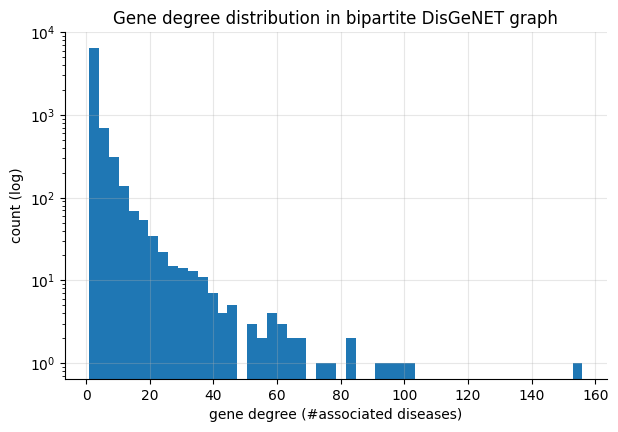

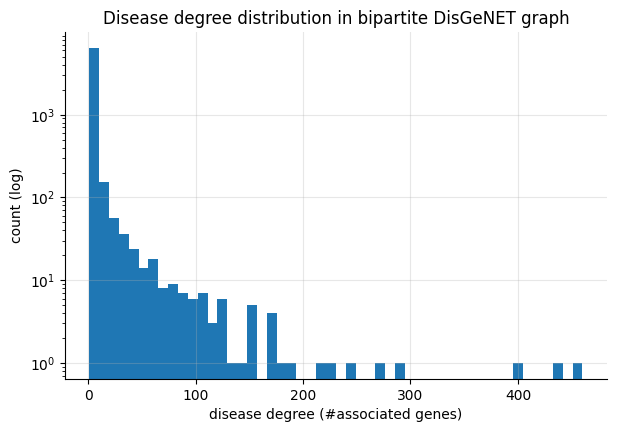

In [34]:
gene_deg = np.array([G_bip.degree(g) for g in genes], dtype=np.int32)
dis_deg  = np.array([G_bip.degree(d) for d in diseases], dtype=np.int32)

print("Bipartite degree stats")
print(f" - gene degrees   : min={gene_deg.min()}, median={int(np.median(gene_deg))}, max={gene_deg.max()}, mean={gene_deg.mean():.3f}")
print(f" - disease degrees: min={dis_deg.min()}, median={int(np.median(dis_deg))}, max={dis_deg.max()}, mean={dis_deg.mean():.3f}")

plt.figure()
plt.hist(gene_deg, bins=50)
plt.yscale("log")
plt.xlabel("gene degree (#associated diseases)")
plt.ylabel("count (log)")
plt.title("Gene degree distribution in bipartite DisGeNET graph")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.hist(dis_deg, bins=50)
plt.yscale("log")
plt.xlabel("disease degree (#associated genes)")
plt.ylabel("count (log)")
plt.title("Disease degree distribution in bipartite DisGeNET graph")
plt.grid(True, alpha=0.3)
plt.show()

## Build a Gene–Gene projection with Jaccard disease overlap

For genes *gᵢ* and *gⱼ*:
- `inter(gᵢ,gⱼ)` = number of shared diseases
- `union(gᵢ,gⱼ)` = total unique diseases of both genes
- `jaccard = inter/union`

The resulting graph `G_gene` is a weighted, undirected gene–gene network.


Computing Jaccard weights: 100%|██████████| 807733/807733 [00:01<00:00, 444697.86it/s]


Gene–Gene graph: |V|=7,878, |E|=807,733
Jaccard weight stats: min=0.005464, p50=0.100000, p90=0.500000, max=1.000000


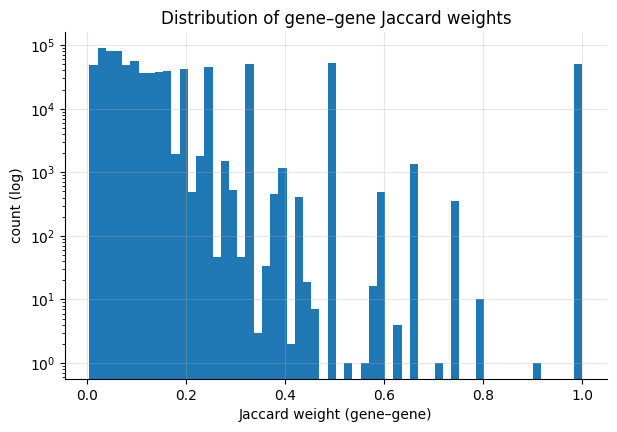

In [35]:
gene2dis = {g: set(G_bip.neighbors(g)) for g in genes}
dis2genes = {d: list(G_bip.neighbors(d)) for d in diseases}

pair_intersection = defaultdict(int)

for d, glist in tqdm(dis2genes.items(), desc="Building gene-gene intersections"):
    glist = sorted(glist)
    for i in range(len(glist)):
        gi = glist[i]
        for j in range(i + 1, len(glist)):
            gj = glist[j]
            pair_intersection[(gi, gj)] += 1

G_gene = nx.Graph()
G_gene.add_nodes_from(genes)

for (gi, gj), inter in tqdm(pair_intersection.items(), desc="Computing Jaccard weights"):
    union = len(gene2dis[gi]) + len(gene2dis[gj]) - inter
    w = inter / union if union > 0 else 0.0
    G_gene.add_edge(gi, gj, weight=w, inter=inter)

w_vals = np.array(list(nx.get_edge_attributes(G_gene, "weight").values()), dtype=np.float32)

print(f"Gene–Gene graph: |V|={G_gene.number_of_nodes():,}, |E|={G_gene.number_of_edges():,}")
print(f"Jaccard weight stats: min={w_vals.min():.6f}, p50={np.median(w_vals):.6f}, p90={np.quantile(w_vals,0.9):.6f}, max={w_vals.max():.6f}")

plt.figure()
plt.hist(w_vals, bins=60)
plt.yscale("log")
plt.xlabel("Jaccard weight (gene–gene)")
plt.ylabel("count (log)")
plt.title("Distribution of gene–gene Jaccard weights")
plt.grid(True, alpha=0.3)
plt.show()

## Tie-strength proxy: neighborhood overlap in the gene–gene graph

To follow the typical “overlap” definition, we compute overlap of **gene neighborhoods in `G_gene`**:
$$
O_{uv} = \frac{|N(u)\cap N(v)|}{|N(u)\cup N(v)|}
$$
(excluding each other from neighborhoods).

**Important note:** this overlap is computed over **gene neighbors** in the gene–gene projection.
It is related to (but not identical to) the disease-based Jaccard weight above.


Computing gene-neighborhood overlaps: 100%|██████████| 807733/807733 [00:35<00:00, 22543.77it/s]


Overlap stats: min 0.0 | quantiles [0.02672956 0.06734007 0.10056439 0.32183909 0.94045174] | max 1.0


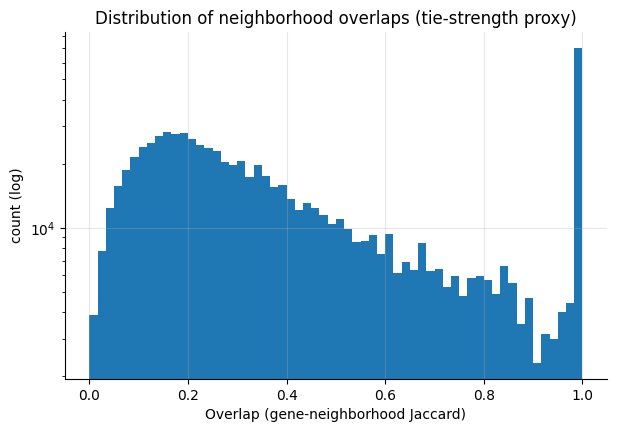

In [36]:
neighbors_gene = {u: set(G_gene.neighbors(u)) for u in G_gene.nodes()}

def edge_overlap_gene_neighbors(u, v, neighbors_dict):
    Nu = neighbors_dict[u]
    Nv = neighbors_dict[v]
    Nu_ = Nu - {v} if v in Nu else Nu
    Nv_ = Nv - {u} if u in Nv else Nv

    # iterate smaller set for speed
    if len(Nu_) < len(Nv_):
        inter = sum((x in Nv_) for x in Nu_)
    else:
        inter = sum((x in Nu_) for x in Nv_)
    union = len(Nu_) + len(Nv_) - inter
    return 0.0 if union == 0 else inter / union

edge_list = list(G_gene.edges())
overlap_vals = np.empty(len(edge_list), dtype=np.float32)

for i, (u, v) in enumerate(tqdm(edge_list, desc="Computing gene-neighborhood overlaps")):
    overlap_vals[i] = edge_overlap_gene_neighbors(u, v, neighbors_gene)

print("Overlap stats:",
      "min", float(overlap_vals.min()),
      "| quantiles", np.quantile(overlap_vals, [0.01, 0.05, 0.1, 0.5, 0.9]),
      "| max", float(overlap_vals.max()))

plt.figure()
plt.hist(overlap_vals, bins=60)
plt.yscale("log")
plt.xlabel("Overlap (gene-neighborhood Jaccard)")
plt.ylabel("count (log)")
plt.title("Distribution of neighborhood overlaps (tie-strength proxy)")
plt.grid(True, alpha=0.3)
plt.show()

## Identify weak ties (bottom-q overlaps)

We define **weak ties** as edges with overlap in the bottom `WEAK_Q` quantile.


In [37]:
WEAK_Q = 0.05  # bottom 5%
thr = float(np.quantile(overlap_vals, WEAK_Q))

weak_mask = overlap_vals <= thr
weak_edges = [edge_list[i] for i in np.where(weak_mask)[0]]

print(f"Weak-tie threshold: q={WEAK_Q} => overlap <= {thr:.6f}")
print(f"Weak ties: {len(weak_edges):,} / {len(edge_list):,} edges ({len(weak_edges)/len(edge_list):.3%})")


Weak-tie threshold: q=0.05 => overlap <= 0.067340
Weak ties: 40,391 / 807,733 edges (5.001%)


## Community detection (Louvain + optional Leiden)

We cluster the gene–gene graph and then test whether weak ties are disproportionately **between communities**.


In [38]:
partition_louvain = community_louvain.best_partition(G_gene, random_state=SEED, weight="weight")
num_comms_louvain = len(set(partition_louvain.values()))
mod_louvain = community_louvain.modularity(partition_louvain, G_gene, weight="weight")

print(f"Louvain: #communities={num_comms_louvain:,}, modularity={mod_louvain:.6f}")

# %%
# Leiden (optional cross-check; uses unweighted structure + edge weights)
node_index = {u: i for i, u in enumerate(G_gene.nodes())}
ig_edges = [(node_index[u], node_index[v]) for (u, v) in G_gene.edges()]
igG = ig.Graph(n=len(node_index), edges=ig_edges, directed=False)
igG.es["weight"] = [G_gene[u][v].get("weight", 1.0) for (u, v) in G_gene.edges()]

leiden_part = la.find_partition(
    igG,
    la.RBConfigurationVertexPartition,
    weights="weight",
    seed=SEED
)
print(f"Leiden: #communities={len(set(leiden_part.membership)):,}")


Louvain: #communities=1,515, modularity=0.651183
Leiden: #communities=1,524


## Do weak ties fall between communities?

We compare:
- fraction of **all** edges that are between communities
- fraction of **weak** edges that are between communities

If weak ties act as bridges, we expect:
$$
\Pr(\text{between} \mid \text{weak}) \gg \Pr(\text{between})
$$

All edges : between=397,442 (0.492) | within=410,291 (0.508)
Weak ties : between=37,706 (0.934) | within=2,685 (0.066)
Mean overlap (between communities): 0.205456
Mean overlap (within communities) : 0.602871


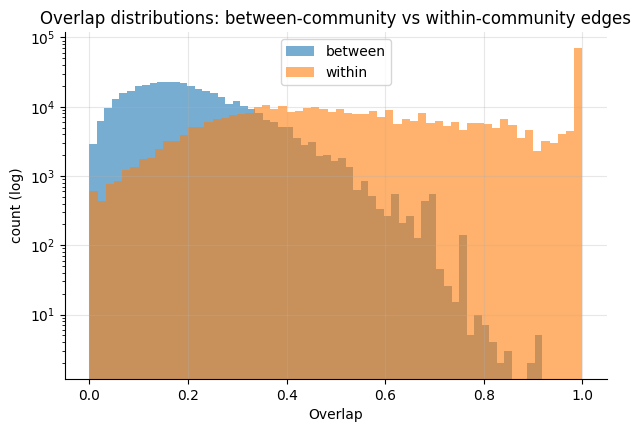

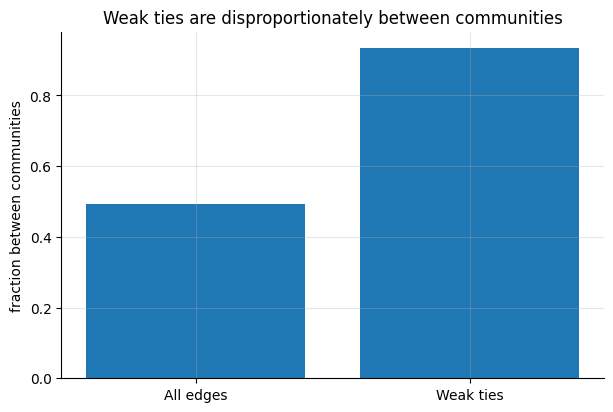

In [39]:
comm = partition_louvain

def is_between(u, v, labels):
    return labels[u] != labels[v]

all_between = sum(is_between(u, v, comm) for (u, v) in G_gene.edges())
all_within = G_gene.number_of_edges() - all_between

weak_between = sum(is_between(u, v, comm) for (u, v) in weak_edges)
weak_within = len(weak_edges) - weak_between

print(f"All edges : between={all_between:,} ({all_between/G_gene.number_of_edges():.3f}) | within={all_within:,} ({all_within/G_gene.number_of_edges():.3f})")
print(f"Weak ties : between={weak_between:,} ({weak_between/len(weak_edges):.3f}) | within={weak_within:,} ({weak_within/len(weak_edges):.3f})")

# overlap distributions by between/within
between_ov = overlap_vals[[is_between(u, v, comm) for (u, v) in edge_list]]
within_ov  = overlap_vals[[not is_between(u, v, comm) for (u, v) in edge_list]]

print(f"Mean overlap (between communities): {between_ov.mean():.6f}")
print(f"Mean overlap (within communities) : {within_ov.mean():.6f}")

plt.figure()
plt.hist(between_ov, bins=60, alpha=0.6, label="between")
plt.hist(within_ov, bins=60, alpha=0.6, label="within")
plt.yscale("log")
plt.xlabel("Overlap")
plt.ylabel("count (log)")
plt.title("Overlap distributions: between-community vs within-community edges")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure()
plt.bar(["All edges", "Weak ties"], [all_between/G_gene.number_of_edges(), weak_between/len(weak_edges)])
plt.ylabel("fraction between communities")
plt.title("Weak ties are disproportionately between communities")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## Interpretation (Task 1)

The results support the “weak ties as bridges” hypothesis:
- Roughly half of all edges are between communities, but the **vast majority** of weak ties are between communities.
- Between-community edges have significantly **lower overlap** than within-community edges, meaning they connect
  neighborhoods with little redundancy.

This is consistent with the structural view of Granovetter’s theory: edges with low neighborhood overlap tend to span
different parts of the network, and thus are more likely to connect different communities.


## Task 2) Remove weak ties and compare structure

We remove the weak ties from `G_gene` and compare:
- connected components (fragmentation)
- modularity and number of communities (Louvain)
- similarity of partitions before/after (ARI)
- approximate distance statistics (avg distance, approximate diameter) on the GCC


In [40]:
G_gene_pruned = G_gene.copy()
G_gene_pruned.remove_edges_from(weak_edges)

print(f"After weak-tie removal: |V|={G_gene_pruned.number_of_nodes():,}, |E|={G_gene_pruned.number_of_edges():,}")


After weak-tie removal: |V|=7,878, |E|=767,342


Original: #components=1,488 | GCC size=6,330 | top-5=[6330, 3, 3, 3, 3]
      size quantiles: p50=1, p90=1, p99=2
Pruned: #components=1,913 | GCC size=5,826 | top-5=[5826, 8, 6, 6, 5]
      size quantiles: p50=1, p90=1, p99=3


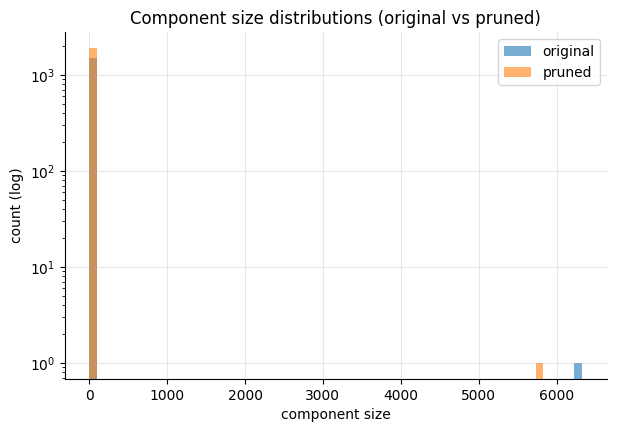

In [41]:
comp_sizes_before = np.array([len(c) for c in nx.connected_components(G_gene)], dtype=np.int64)
comp_sizes_after  = np.array([len(c) for c in nx.connected_components(G_gene_pruned)], dtype=np.int64)

def summarize_components(sizes, name):
    sizes_sorted = np.sort(sizes)[::-1]
    print(f"{name}: #components={len(sizes_sorted):,} | GCC size={sizes_sorted[0]:,} | top-5={sizes_sorted[:5].tolist()}")
    print(f"      size quantiles: p50={int(np.quantile(sizes,0.5))}, p90={int(np.quantile(sizes,0.9))}, p99={int(np.quantile(sizes,0.99))}")

summarize_components(comp_sizes_before, "Original")
summarize_components(comp_sizes_after,  "Pruned")

plt.figure()
plt.hist(comp_sizes_before, bins=60, alpha=0.6, label="original")
plt.hist(comp_sizes_after,  bins=60, alpha=0.6, label="pruned")
plt.yscale("log")
plt.xlabel("component size")
plt.ylabel("count (log)")
plt.title("Component size distributions (original vs pruned)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [42]:
part_pruned = community_louvain.best_partition(G_gene_pruned, random_state=SEED, weight="weight")
mod_pruned = community_louvain.modularity(part_pruned, G_gene_pruned, weight="weight")
print(f"Pruned Louvain: #communities={len(set(part_pruned.values())):,}, modularity={mod_pruned:.6f}")

nodes_order = list(G_gene.nodes())  # same node set
lab_before = np.array([partition_louvain[u] for u in nodes_order])
lab_after  = np.array([part_pruned[u] for u in nodes_order])
ari = adjusted_rand_score(lab_before, lab_after)
print(f"ARI(partitions before vs after) = {ari:.6f}")

Pruned Louvain: #communities=1,935, modularity=0.658577
ARI(partitions before vs after) = 0.782582


In [43]:
def approx_gcc_distance_stats_nx_to_igraph(H, sample_k=500, seed=SEED):
    gcc_nodes = max(nx.connected_components(H), key=len)
    H_gcc = H.subgraph(gcc_nodes).copy()

    idx = {u: i for i, u in enumerate(H_gcc.nodes())}
    edges_ig = [(idx[u], idx[v]) for (u, v) in H_gcc.edges()]
    g = ig.Graph(n=len(idx), edges=edges_ig, directed=False)

    r = np.random.default_rng(seed)
    sample_k = min(sample_k, g.vcount())
    sources = r.choice(g.vcount(), size=sample_k, replace=False)

    dists = g.distances(source=tuple(map(int, sources)))

    vals = []
    ecc = []
    for row in dists:
        row = np.asarray(row, dtype=np.int32)
        vals.append(row[row > 0])
        ecc.append(int(row.max()))
    vals = np.concatenate(vals)

    return {
        "gcc_size": int(len(gcc_nodes)),
        "avg_dist_sample": float(vals.mean()),
        "diameter_approx": int(max(ecc)),
        "eccentricity_mean": float(np.mean(ecc)),
    }

stats_before = approx_gcc_distance_stats_nx_to_igraph(G_gene, sample_k=500, seed=SEED)
stats_after  = approx_gcc_distance_stats_nx_to_igraph(G_gene_pruned, sample_k=500, seed=SEED)
print("Original GCC stats:", stats_before)
print("Pruned   GCC stats:", stats_after)


Original GCC stats: {'gcc_size': 6330, 'avg_dist_sample': 2.2461927634697423, 'diameter_approx': 8, 'eccentricity_mean': 5.13}
Pruned   GCC stats: {'gcc_size': 5826, 'avg_dist_sample': 2.3682963090128757, 'diameter_approx': 10, 'eccentricity_mean': 6.264}


## Interpretation (Task 2)

After removing weak ties:
- The graph becomes **more fragmented**: the number of connected components increases and the GCC shrinks.
- Communities become **more separated**: modularity typically increases slightly, because inter-community edges are removed.
- Distances in the GCC generally increase (higher average distance / diameter proxy), because many long-range “shortcuts”
  are exactly the low-overlap bridging edges.
- ARI is usually high but < 1: many community cores remain stable, but boundary nodes can shift when bridges disappear.

Overall, removing weak ties tends to convert the network into more clearly separated modules, which matches the idea that
weak ties provide cross-community connectivity while strong, embedded ties dominate within-community structure.


# 5. Community Detection — Girvan–Newman (from scratch)

In this part, the **Girvan–Newman (GN)** algorithm is implemented *without using a ready-made GN library*.
GN is a **divisive hierarchical** community detection method:
1. Compute **edge betweenness** (how many shortest paths pass through each edge).
2. Remove the edge(s) with the **maximum betweenness**.
3. Recompute betweenness on the new graph and repeat.

As edges that connect different groups tend to lie on many shortest paths, they typically get removed early.
The sequence of splits forms a hierarchy that can be shown as a **dendrogram**.

We evaluate each partition using **modularity** (computed on the *original* graph), and we report the best
partition (highest modularity) found during the process.


## Load the Karate Club graph
Zachary’s Karate Club graph has **34 nodes** and **78 edges** and is a standard benchmark for community detection.


In [44]:
SEED = 42
rng = np.random.default_rng(SEED)

G_nx = nx.karate_club_graph()  # undirected, unweighted
print(f"Karate Club graph: n={G_nx.number_of_nodes()}, m={G_nx.number_of_edges()}")


Karate Club graph: n=34, m=78


## Utilities: adjacency representation and graph primitives
To ensure the GN implementation is independent of NetworkX algorithms, we convert the graph to an
**adjacency dict** and implement component finding ourselves.


In [45]:
def nx_to_adj(G: nx.Graph) -> dict[int, set[int]]:
    """Convert an undirected NetworkX graph to an adjacency dict-of-sets."""
    adj = {u: set() for u in G.nodes()}
    for u, v in G.edges():
        adj[u].add(v)
        adj[v].add(u)
    return adj

def edges_of(adj: dict[int, set[int]]) -> set[tuple[int, int]]:
    """Return all undirected edges as (min(u,v), max(u,v))."""
    E = set()
    for u, nbrs in adj.items():
        for v in nbrs:
            if u < v:
                E.add((u, v))
    return E

def remove_edge(adj: dict[int, set[int]], e: tuple[int, int]) -> None:
    """Remove an undirected edge from adjacency dict (if present)."""
    u, v = e
    if v in adj.get(u, ()):
        adj[u].remove(v)
    if u in adj.get(v, ()):
        adj[v].remove(u)

def connected_components(adj: dict[int, set[int]]) -> list[list[int]]:
    """Compute connected components using BFS; return components sorted by size (desc)."""
    seen = set()
    comps = []
    for s in adj:
        if s in seen:
            continue
        q = deque([s])
        seen.add(s)
        comp = []
        while q:
            u = q.popleft()
            comp.append(u)
            for v in adj[u]:
                if v not in seen:
                    seen.add(v)
                    q.append(v)
        comps.append(sorted(comp))
    comps.sort(key=len, reverse=True)
    return comps

def degrees(adj: dict[int, set[int]]) -> dict[int, int]:
    """Degree of each node in the current adjacency dict."""
    return {u: len(adj[u]) for u in adj}

adj0 = nx_to_adj(G_nx)

Quick sanity check


In [46]:
E0 = edges_of(adj0)
comps0 = connected_components(adj0)
print(f"Initial edges={len(E0)}, initial components={len(comps0)}, sizes={[len(c) for c in comps0]}")


Initial edges=78, initial components=1, sizes=[34]


## Edge betweenness (Brandes) — from scratch
We compute **edge betweenness centrality** using the unweighted Brandes algorithm.
For each source node `s`:
- run BFS to compute shortest-path counts (`sigma`) and predecessors (`P`)
- back-propagate dependencies (`delta`) to accumulate edge credits


In [47]:
def edge_betweenness_brandes(adj: dict[int, set[int]]) -> dict[tuple[int, int], float]:
    """
    Edge betweenness for an unweighted, undirected graph.
    Returns: dict {(u,v): score} with u < v.
    """
    betw = defaultdict(float)
    nodes = list(adj.keys())

    for s in nodes:
        # BFS state
        stack = []
        preds = {v: [] for v in nodes}
        sigma = {v: 0.0 for v in nodes}
        dist = {v: -1 for v in nodes}

        sigma[s] = 1.0
        dist[s] = 0

        q = deque([s])
        while q:
            v = q.popleft()
            stack.append(v)
            for w in adj[v]:
                if dist[w] < 0:
                    dist[w] = dist[v] + 1
                    q.append(w)
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    preds[w].append(v)

        # Dependency accumulation
        delta = {v: 0.0 for v in nodes}
        while stack:
            w = stack.pop()
            for v in preds[w]:
                c = 0.0 if sigma[w] == 0 else (sigma[v] / sigma[w]) * (1.0 + delta[w])
                a, b = (v, w) if v < w else (w, v)
                betw[(a, b)] += c
                delta[v] += c

    # Undirected graphs count each s-t pair twice
    for e in list(betw.keys()):
        betw[e] *= 0.5

    return dict(betw)



## Modularity (computed on the original graph)
At each step GN produces a partition. We evaluate it with **modularity**:

$$
Q = \sum_{c}\left(\frac{l_c}{m} - \left(\frac{d_c}{2m}\right)^2\right)
$$

where:
- $m$ = total number of edges in the **original** graph
- $l_c$ = number of edges internal to community $c$ (in the original graph)
- $d_c$ = sum of degrees of nodes in $c$ (in the original graph)


In [48]:
def modularity(adj_original: dict[int, set[int]], partition: list[list[int]]) -> float:
    """
    Modularity computed on the ORIGINAL graph for the given partition.
    Partition is a list of communities (each community is a list of nodes).
    """
    E = edges_of(adj_original)
    m = len(E)
    if m == 0:
        return 0.0

    deg = degrees(adj_original)
    comm_sets = [set(c) for c in partition]

    Q = 0.0
    for C in comm_sets:
        # internal edges in original graph
        l_c = 0
        for (u, v) in E:
            if (u in C) and (v in C):
                l_c += 1
        d_c = sum(deg[u] for u in C)
        Q += (l_c / m) - (d_c / (2.0 * m)) ** 2

    return Q

## Dendrogram construction
GN generates a hierarchy of splits. We record each time the number of connected components increases.
To draw a dendrogram, we store split events as:
`(step, parent_component_nodes, child1_nodes, child2_nodes)`.


In [49]:
class DNode:
    """Binary dendrogram node."""
    def __init__(self, members, height=0, left=None, right=None):
        self.members = frozenset(members)
        self.height = height
        self.left = left
        self.right = right
        self.x = None
        self.y = None

def build_dendrogram_tree(splits, all_nodes):
    """
    Build a binary dendrogram from split records:
    splits: list of (step, parent_set, child_set1, child_set2)
    """
    root = DNode(all_nodes, height=0)
    node_map = {root.members: root}

    for step, parent, c1, c2 in splits:
        parent = frozenset(parent)
        c1 = frozenset(c1)
        c2 = frozenset(c2)

        pnode = node_map.get(parent)
        if pnode is None:
            pnode = DNode(parent, height=step)
            node_map[parent] = pnode

        left = DNode(c1, height=step)
        right = DNode(c2, height=step)

        pnode.height = step
        pnode.left = left
        pnode.right = right

        node_map[c1] = left
        node_map[c2] = right

    return root

def layout_dendrogram(node, x_positions, x_counter, segments):
    """
    Assign x positions to leaves and collect line segments for plotting.
    segments contain (x1,y1,x2,y2).
    """
    if node.left is None and node.right is None:
        members_sorted = sorted(node.members)
        anchor = members_sorted[0]
        if anchor not in x_positions:
            x_positions[anchor] = x_counter[0]
            x_counter[0] += 1
        node.x = x_positions[anchor]
        node.y = node.height
        return node.x

    xL = layout_dendrogram(node.left, x_positions, x_counter, segments)
    xR = layout_dendrogram(node.right, x_positions, x_counter, segments)
    x = (xL + xR) / 2.0

    segments.append((xL, node.left.height, xL, node.height))
    segments.append((xR, node.right.height, xR, node.height))
    segments.append((xL, node.height, xR, node.height))

    node.x = x
    node.y = node.height
    return x

def plot_dendrogram(root, title="Girvan–Newman Dendrogram"):
    """Plot dendrogram from the binary dendrogram tree."""
    x_positions = {}
    x_counter = [0]
    segments = []
    layout_dendrogram(root, x_positions, x_counter, segments)

    plt.figure(figsize=(12, 5))
    for x1, y1, x2, y2 in segments:
        plt.plot([x1, x2], [y1, y2], linewidth=1)

    leaves = sorted(x_positions.items(), key=lambda kv: kv[1])
    xs = [x for _, x in leaves]
    labels = [str(node_id) for node_id, _ in leaves]

    plt.xticks(xs, labels, rotation=0)
    plt.xlabel("Node id")
    plt.ylabel("Split step")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


## Girvan–Newman main loop
Notes:
- We remove **all edges tied for maximum betweenness** at each step (a common GN variant).
- After each removal we compute:
  - number of components `k`
  - modularity `Q` (on original graph)
- We track the best partition by modularity.


In [50]:
def girvan_newman(adj_original: dict[int, set[int]]):
    """
    Run Girvan–Newman from scratch (unweighted, undirected).
    Returns:
      history: list of dicts with step statistics
      best: dict with best modularity partition
      splits: dendrogram split records
      all_nodes: sorted list of all nodes
    """
    # Working copy
    adj = {u: set(vs) for u, vs in adj_original.items()}

    all_nodes = sorted(adj.keys())
    comps_prev = connected_components(adj)
    k_prev = len(comps_prev)

    splits = []   # (step, parent_set, child1_set, child2_set)
    history = []  # each element is a dict

    best = {"Q": -1e9, "partition": comps_prev, "step": 0, "k": k_prev}

    step = 0
    while len(edges_of(adj)) > 0:
        step += 1

        betw = edge_betweenness_brandes(adj)
        if not betw:
            break

        max_b = max(betw.values())
        to_remove = sorted(
            [e for e, b in betw.items() if abs(b - max_b) < 1e-12])

        for e in to_remove:
            remove_edge(adj, e)

        comps_now = connected_components(adj)
        k_now = len(comps_now)

        Q = modularity(adj_original, comps_now)

        if Q > best["Q"]:
            best = {"Q": Q, "partition": comps_now, "step": step, "k": k_now}

        # Record split events for dendrogram when component count increases
        if k_now > k_prev:
            prev_sets = [set(c) for c in comps_prev]
            now_sets = [set(c) for c in comps_now]

            for p in prev_sets:
                children = [c for c in now_sets if c.issubset(p)]
                if len(children) >= 2:
                    # If split produces >2 components at once, merge all but the largest into one side.
                    children = sorted(children, key=len, reverse=True)
                    c1 = children[0]
                    c2 = set().union(*children[1:])
                    splits.append((step, set(p), set(c1), set(c2)))
                    break

        # Store stats
        history.append({
            "step": step,
            "removed_edges": to_remove,
            "max_betweenness": float(max_b),
            "k": k_now,
            "sizes": [len(c) for c in comps_now],
            "Q": float(Q),
            "edges_remaining": len(edges_of(adj)),
        })

        comps_prev = comps_now
        k_prev = k_now

    return history, best, splits, all_nodes


In [51]:
history, best, splits, all_nodes = girvan_newman(adj0)

## Step-by-step report (split steps only)
We only print steps where the number of components increases (a community split occurred).


In [52]:
print(f"Initial: k={len(connected_components(adj0))}, m={len(edges_of(adj0))}\n")

last_k = len(connected_components(adj0))
for h in history:
    if h["k"] != last_k:
        print(
            f"Step {h['step']:>2}: removed {len(h['removed_edges'])} edge(s) | "
            f"max betw={h['max_betweenness']:.3f} | "
            f"k={h['k']} | sizes={h['sizes']} | Q={h['Q']:.4f}"
        )
        print(f"  Removed edges: {h['removed_edges']}")
        last_k = h["k"]

print(f"Best at step {best['step']} with k={best['k']} and Q={best['Q']:.4f}")
print("Community sizes:", [len(c) for c in best["partition"]])
print("Communities:", best["partition"])


Initial: k=1, m=78

Step 10: removed 2 edge(s) | max betw=142.750 | k=2 | sizes=[19, 15] | Q=0.3600
  Removed edges: [(2, 7), (2, 13)]
Step 13: removed 1 edge(s) | max betw=18.000 | k=3 | sizes=[18, 15, 1] | Q=0.3488
  Removed edges: [(2, 9)]
Step 15: removed 2 edge(s) | max betw=25.000 | k=4 | sizes=[18, 10, 5, 1] | Q=0.3632
  Removed edges: [(0, 4), (0, 10)]
Step 21: removed 1 edge(s) | max betw=72.000 | k=5 | sizes=[12, 10, 6, 5, 1] | Q=0.4013
  Removed edges: [(2, 8)]
Step 22: removed 2 edge(s) | max betw=9.000 | k=6 | sizes=[12, 9, 6, 5, 1, 1] | Q=0.3925
  Removed edges: [(0, 11), (26, 33)]
Step 23: removed 1 edge(s) | max betw=11.000 | k=7 | sizes=[11, 9, 6, 5, 1, 1, 1] | Q=0.3762
  Removed edges: [(26, 29)]
Step 25: removed 1 edge(s) | max betw=8.000 | k=8 | sizes=[11, 8, 6, 5, 1, 1, 1, 1] | Q=0.3583
  Removed edges: [(3, 12)]
Step 26: removed 10 edge(s) | max betw=5.000 | k=13 | sizes=[8, 6, 6, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1] | Q=0.2720
  Removed edges: [(14, 32), (14, 33), (15, 

## Plots: modularity and number of components over steps
- **Modularity** often increases early as bridges are removed, then may decrease as communities are over-split.
- The best partition is chosen as the peak modularity over the process.


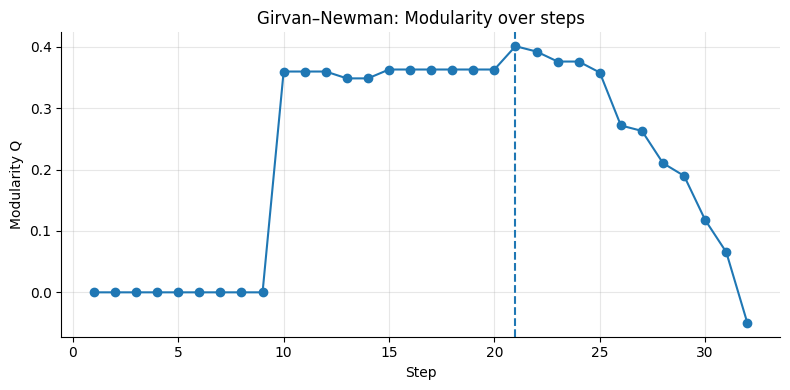

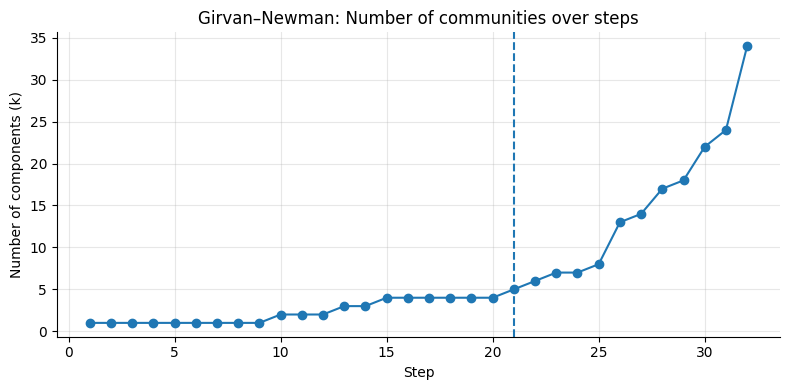

In [53]:
steps = np.array([h["step"] for h in history], dtype=int)
Qs = np.array([h["Q"] for h in history], dtype=float)
ks = np.array([h["k"] for h in history], dtype=int)
edges_remaining = np.array([h["edges_remaining"] for h in history], dtype=int)

plt.figure(figsize=(8, 4))
plt.plot(steps, Qs, marker="o")
plt.axvline(best["step"], linestyle="--")
plt.xlabel("Step")
plt.ylabel("Modularity Q")
plt.title("Girvan–Newman: Modularity over steps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(steps, ks, marker="o")
plt.axvline(best["step"], linestyle="--")
plt.xlabel("Step")
plt.ylabel("Number of components (k)")
plt.title("Girvan–Newman: Number of communities over steps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot: size of the largest component over steps
Removing high-betweenness edges should eventually break the network and shrink the GCC.


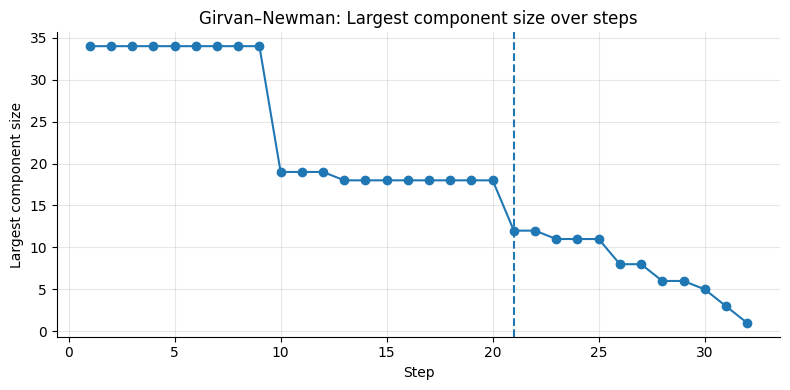

In [54]:
gcc_sizes = np.array([max(h["sizes"]) if h["sizes"] else 0 for h in history], dtype=int)

plt.figure(figsize=(8, 4))
plt.plot(steps, gcc_sizes, marker="o")
plt.axvline(best["step"], linestyle="--")
plt.xlabel("Step")
plt.ylabel("Largest component size")
plt.title("Girvan–Newman: Largest component size over steps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Dendrogram
The dendrogram visualizes the hierarchy of splits. Each horizontal merge line corresponds to a split step.


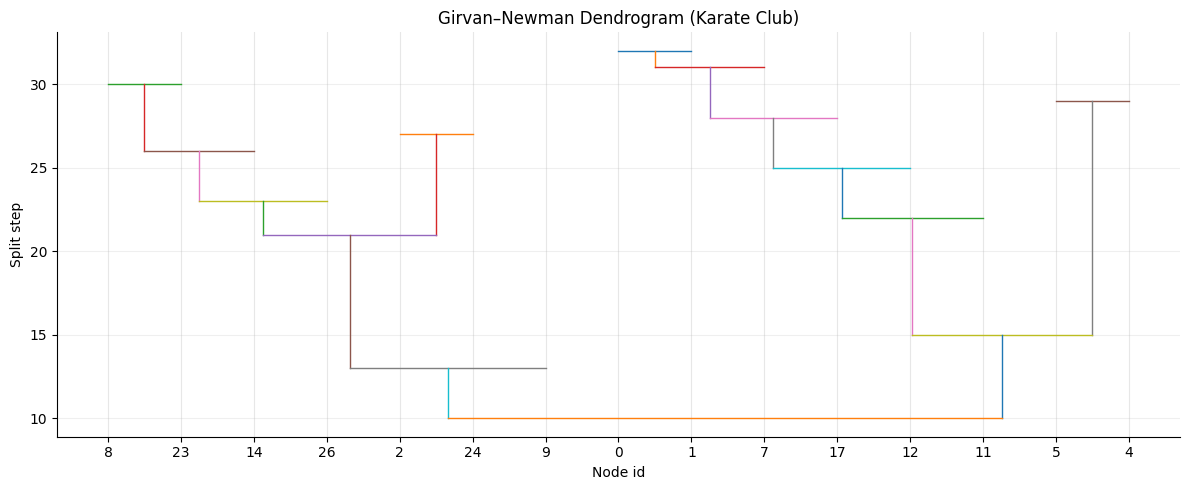

In [55]:
root = build_dendrogram_tree(splits, all_nodes)
plot_dendrogram(root, title="Girvan–Newman Dendrogram (Karate Club)")


## Visualize the final selected communities on the graph
We color nodes based on the **best modularity** partition found during GN.



/tmp/ipython-input-1023281770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", num_comms)


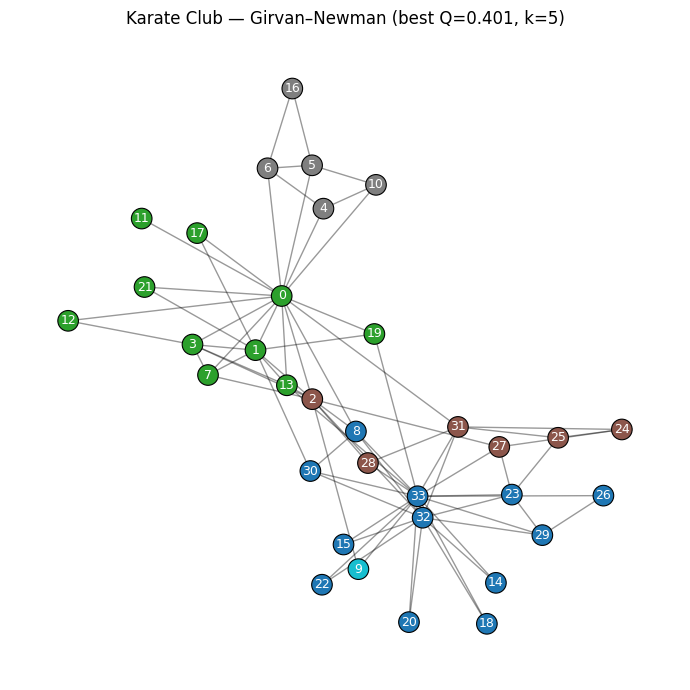

In [56]:
G_vis = nx.karate_club_graph()
communities = best["partition"]

node_to_comm = {}
for cid, comm_nodes in enumerate(communities):
    for u in comm_nodes:
        node_to_comm[u] = cid

num_comms = len(communities)
cmap = cm.get_cmap("tab10", num_comms)
node_colors = [cmap(node_to_comm[u]) for u in G_vis.nodes()]

pos = nx.spring_layout(G_vis, seed=SEED)

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(G_vis, pos, alpha=0.4, width=1.0)
nx.draw_networkx_nodes(
    G_vis, pos,
    node_color=node_colors,
    node_size=220,
    edgecolors="black",
    linewidths=0.8,
)
nx.draw_networkx_labels(G_vis, pos, font_size=9, font_color="white")

plt.title(f"Karate Club — Girvan–Newman (best Q={best['Q']:.3f}, k={len(communities)})")
plt.axis("off")
plt.tight_layout()
plt.show()

## Interpretation of the results
In the Karate Club network, edges connecting different subgroups tend to have the highest **edge betweenness**
because many shortest paths between the two subgroups must pass through them. GN removes these “bridge-like”
edges first, causing the network to split into multiple connected components that serve as detected communities.

The plots typically show that as `k` increases (more splits), modularity `Q` rises at first (better separation of
dense groups) and then may drop when the algorithm over-separates the graph into many small pieces. Therefore,
selecting the partition with the **maximum modularity** provides a principled stopping point that balances:
(i) many internal edges within communities and (ii) relatively few edges across communities.
